### Projeto: Teste A/B - Checkout Automático vs Manual
### Empresa fictícia: Eletronic House

### Objetivo: Verificar se o preenchimento automático dos dados de cartão de crédito no checkout resulta em maior receita (GMV) em relação ao preenchimento manual.

## 0.0 setup

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pingouin as pg

from statsmodels.stats import api as sms
from scipy import stats

## 1. carregamento e limpeza dos dados

In [70]:
dfraw = pd.read_csv('data/ab_testing.csv')
df = dfraw.copy()

In [71]:
# conversão de data
df['date'] = pd.to_datetime(df['date'])

In [72]:
# filtrando apenas Brasil
df = df[df['country'] == 'BRA']

## 2. validação dos dados

In [81]:
# checar balanceamento entre grupos
df['group'].value_counts()

group
GRP A    4518
GRP B    4491
Name: count, dtype: int64

In [80]:
# checar valores nulos
df.isna().sum()

uid          0
country      0
gender       0
spent        0
purchases    0
date         0
group        0
device       0
dtype: int64

In [79]:
# checar se algum UID está duplicado nos grupos
df.groupby('uid')['group'].nunique().value_counts()

group
1    9009
Name: count, dtype: int64

## 3. análise exploratória

In [73]:
display(df.describe())

,uid,spent,purchases,date
count,9.009000e+03,9009.000000,9009.000000,9009
mean,5.572287e+07,1902.860251,4.576757,2017-01-10 14:21:32.307692288
min,1.114314e+07,99.000000,1.000000,2014-03-04 00:00:00
25%,3.342811e+07,897.000000,2.000000,2016-08-12 00:00:00
50%,5.586956e+07,1596.000000,4.000000,2017-02-21 00:00:00
75%,7.813106e+07,2593.000000,6.000000,2017-08-09 00:00:00
max,9.999699e+07,10480.000000,24.000000,2018-01-26 00:00:00
std,2.566981e+07,1398.886279,3.151080,NaN


### 3.1 distribuição de participantes por grupo

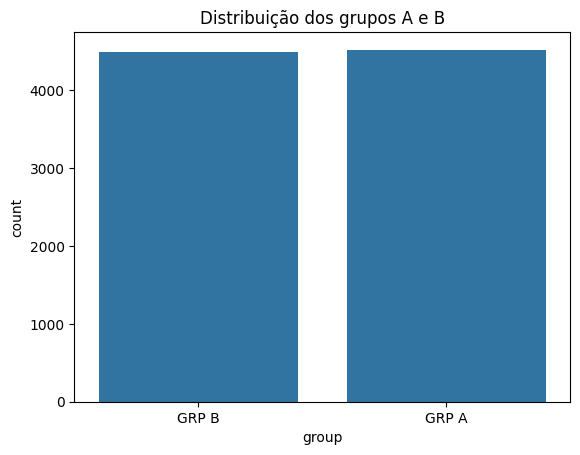

In [74]:
sns.countplot(data=df, x='group')
plt.title('Distribuição dos grupos A e B')
plt.show()

### 3.2 distribuição de gastos por grupo

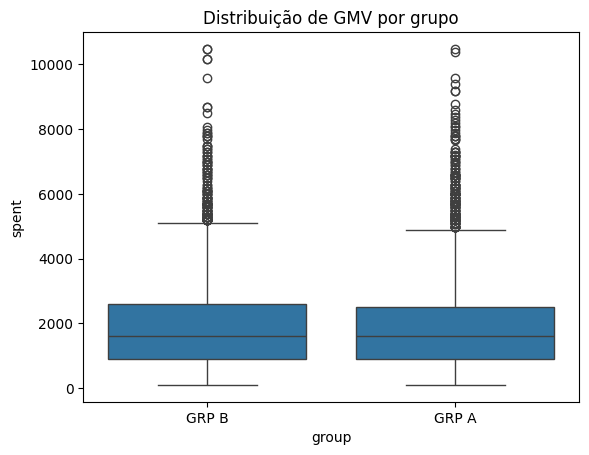

In [75]:
sns.boxplot(data=df, x='group', y='spent')
plt.title('Distribuição de GMV por grupo')
plt.show()

## 4. Hipótese Estatística

##### H0: GMV médio do grupo A = GMV médio do grupo B (Hipótese Nula)
##### H1: GMV médio dos grupos A e B são diferentes (Hipótese Alternativa)

In [83]:
# métricas iniciais do grupo A
gmv_mean = df[df['group'] == 'GRP A']['spent'].mean()
gmv_std = df[df['group'] == 'GRP A']['spent'].std()

# quero detectar um aumento de 5%
lift = 0.05
effect_size = (gmv_mean * (1 + lift) - gmv_mean) / gmv_std

# tamanho de amostra ideal
sample_size = math.ceil(sms.tt_ind_solve_power(
    effect_size=effect_size, alpha=0.05, power=0.8))
print(f"Tamanho de amostra calculado: {sample_size}")

Tamanho de amostra calculado: 3475


## 5. Coleta de amostras

In [85]:
sample_A = df[df['group'] == 'GRP A']['spent'].sample(n=sample_size, random_state=42)
sample_B = df[df['group'] == 'GRP B']['spent'].sample(n=sample_size, random_state=42)

# validação de normalidade e variância
shapiro_A = stats.shapiro(sample_A)
shapiro_B = stats.shapiro(sample_B)
levene_test = stats.levene(sample_A, sample_B)

print("Teste de Normalidade (Shapiro-Wilk):")
print(f" - Amostra A: estatística = {shapiro_A.statistic:.4f}, p-valor = {shapiro_A.pvalue:.4e}")
print(f" - Amostra B: estatística = {shapiro_B.statistic:.4f}, p-valor = {shapiro_B.pvalue:.4e}")

print("\nTeste de Homogeneidade de Variâncias (Levene):")
print(f" - estatística = {levene_test.statistic:.4f}, p-valor = {levene_test.pvalue:.4f}")

Teste de Normalidade (Shapiro-Wilk):
 - Amostra A: estatística = 0.8839, p-valor = 2.9295e-45
 - Amostra B: estatística = 0.8967, p-valor = 2.0213e-43

Teste de Homogeneidade de Variâncias (Levene):
 - estatística = 0.1120, p-valor = 0.7379


## 6. Teste t (paramétrico)

In [86]:
t_stat, p_value = stats.ttest_ind(sample_A, sample_B)
print(f"p-value: {p_value}")

p-value: 0.7191302924096752


## 7. Conclusão

In [ ]:
significance_level = 0.05
if p_value < significance_level:
    print('Resultado: Rejeitamos a Hipótese Nula')
    print('Conclusão: O novo checkout automático gera diferença significativa no GMV')
else:
    print('Resultado: Não rejeitamos a Hipótese Nula')
    print('Conclusão: Não há evidências suficientes de que o checkout automático seja melhor')
    
# Resultado: Não rejeitamos a Hipótese Nula
# Conclusão: Não há evidências suficientes de que o checkout automático seja melhor